Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6541.7715 - val_loss: 6312.9155
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6145.5547 - val_loss: 6078.5986
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6009.1040 - val_loss: 5688.2417
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5583.1128 - val_loss: 5084.2139
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4978.1523 - val_loss: 4237.5098
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4064.9248 - val_loss: 3204.0752
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2928.4407 - val_loss: 2139.5740
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1856.8076 - val_loss: 1242.4586
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1115.7129 - val_loss: 687.1447
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 601.0720 - val_loss: 442.2368
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 438.5594 - val_loss: 367.6588
Epoch 12/

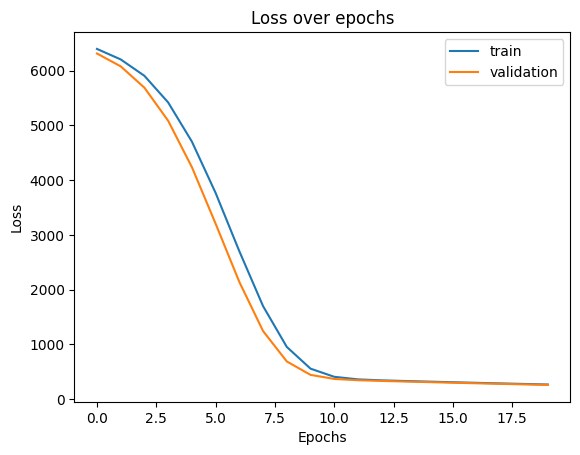

In [2]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split
import pandas as pd


X = pd.read_csv('./datasets/scaled_features.csv').values
y = pd.read_csv('./datasets/encoded_labels.csv').values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2)  # 80% train, 20% validation

model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)  # No activation for regression
])

# Mean Squared Error for regression
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20)
model.save('./models/plant_health_model.keras')

# Plotting the training and validation loss
history = model.history.history
plt.plot(history['loss'], label='train')
plt.plot(history['val_loss'], label='validation')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
